<a href="https://colab.research.google.com/github/artemyarosh/business_analyst_notes/blob/main/stock_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries installation & import

In [ ]:
pip install pyodbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.3/340.3 kB 5.9 MB/s eta 0:00:00


In [ ]:
pip install pypyodbc

  Preparing metadata (setup.py) ... done
  Created wheel for pypyodbc: filename=pypyodbc-1.3.6-py3-none-any.whl size=22857 sha256=523751f8ee98f94e58f36689ebbdc1f3668268e9edd05be08e82cbaea47475d7
  Stored in directory: /root/.cache/pip/wheels/cc/0f/d7/04afb4d86f85c4969168e5a366dbf8c17751159188c2c677ed
Successfully built pypyodbc


In [ ]:
pip install yfinance

In [ ]:
pip install matplotlib

In [ ]:
pip install seaborn

In [ ]:
pip install scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pypyodbc as odbc
import pyodbc

# Data retrieve

In [ ]:
snp = yf.download("^GSPC", start='2020-01-01', end=None)
dell = yf.download("DELL", start='2020-01-01', end=None)
lenovo = yf.download("0992.HK", start='2020-01-01', end=None)
hpe = yf.download("HPE", start='2020-01-01', end=None)

# Use 'Close' column as main data for stocks, resampling data into months
snp_monthly = snp['Close'].resample('1ME').ffill()
dell_monthly = dell['Close'].resample('1ME').ffill()
lenovo_monthly = lenovo['Close'].resample('1ME').ffill()
hpe_monthly = hpe['Close'].resample('1ME').ffill()

/tmp/ipython-input-1273207570.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  snp = yf.download("^GSPC", start='2020-01-01', end=None)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1273207570.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dell = yf.download("DELL", start='2020-01-01', end=None)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1273207570.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  lenovo = yf.download("0992.HK", start='2020-01-01', end=None)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1273207570.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hpe = yf.download("HPE", start='2020-01-01', end=None)
[*********************100%***********************]  1 of 1 completed


# Data Transformation

In [ ]:
# Joining Data
sample = snp_monthly.merge(dell_monthly, left_index=True, right_index=True).merge(lenovo_monthly, left_index=True, right_index=True).merge(hpe_monthly, left_index=True, right_index=True)
sample.columns = ['snp', 'dell', 'lenovo', 'hpe']

In [ ]:
sample

,snp,dell,lenovo,hpe
Date,,,,
2020-01-31,3225.520020,22.660154,3.906627,11.501372
2020-02-29,2954.219971,18.799053,3.662939,10.560123
2020-03-31,2584.590088,18.376240,3.167947,8.104410
2020-04-30,2912.429932,19.835182,3.213638,8.396535
2020-05-31,3044.310059,23.064383,3.206023,8.104410
...,...,...,...,...
2025-09-30,6688.459961,141.266663,11.449821,24.413174
2025-10-31,6840.200195,162.009995,11.261469,24.274010
2025-11-30,6849.089844,133.350006,9.596041,21.739256


In [ ]:
sample

,snp,dell,lenovo,hpe
Date,,,,
2020-01-31,3225.520020,22.660154,3.906627,11.501372
2020-02-29,2954.219971,18.799053,3.662939,10.560123
2020-03-31,2584.590088,18.376240,3.167947,8.104410
2020-04-30,2912.429932,19.835182,3.213638,8.396535
2020-05-31,3044.310059,23.064383,3.206023,8.104410
...,...,...,...,...
2025-09-30,6688.459961,141.266663,11.449821,24.413174
2025-10-31,6840.200195,162.009995,11.261469,24.274010
2025-11-30,6849.089844,133.350006,9.596041,21.739256


In [ ]:
sample['year'] = sample.index.year
sample['month'] = sample.index.month

In [ ]:
sample

,snp,dell,lenovo,hpe,year,month
Date,,,,,,
2020-01-31,3225.520020,22.660154,3.906627,11.501372,2020,1
2020-02-29,2954.219971,18.799053,3.662939,10.560123,2020,2
2020-03-31,2584.590088,18.376240,3.167947,8.104410,2020,3
2020-04-30,2912.429932,19.835182,3.213638,8.396535,2020,4
2020-05-31,3044.310059,23.064383,3.206023,8.104410,2020,5
...,...,...,...,...,...,...
2025-09-30,6688.459961,141.266663,11.449821,24.413174,2025,9
2025-10-31,6840.200195,162.009995,11.261469,24.274010,2025,10
2025-11-30,6849.089844,133.350006,9.596041,21.739256,2025,11


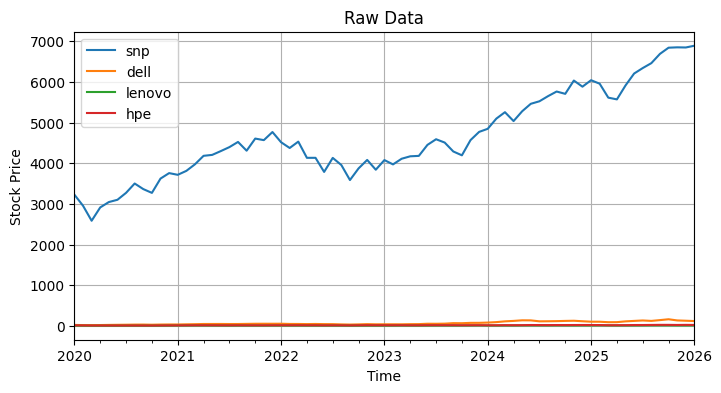

In [ ]:
from matplotlib import pyplot as plt
sample['snp'].plot(kind='line', figsize=(8, 4), title='snp')
sample['dell'].plot(kind='line', figsize=(8, 4), title='dell')
sample['lenovo'].plot(kind='line', figsize=(8, 4), title='lenovo')
sample['hpe'].plot(kind='line', figsize=(8, 4), title='hpe')
plt.legend()
plt.title('Raw Data')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.grid(True)
plt.show()

# Forecasting

In [ ]:
X = sample[['year', 'month']]  # Features
y = sample[['snp', 'dell', 'lenovo', 'hpe']]  # Target

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Adjust test_size and random_state as needed

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from pandas.tseries.offsets import DateOffset

# Generate Future Dates
last_date = sample.index[-1]  # Get the last date in the index
future_dates = [last_date + DateOffset(months=i) for i in range(1, 4)]  # Generate dates for next 3 months

future_features = pd.DataFrame({'year': [d.year for d in future_dates],
                                 'month': [d.month for d in future_dates]},
                                index=future_dates)

# 3. Predict Using the Model
future_predictions = model.predict(future_features)

# 4. Create a DataFrame for Future Predictions
future_predictions_df = pd.DataFrame(future_predictions,
                                     columns=['snp', 'dell', 'lenovo', 'hpe'],
                                     index=future_dates)

In [ ]:
future_predictions_df

,snp,dell,lenovo,hpe
2026-02-28,6226.077645,127.485101,10.656969,21.360303
2026-03-31,6297.660337,129.830989,10.742314,21.613780
2026-04-30,6369.243028,132.176876,10.827660,21.867258


In [ ]:
# 5. Concatenate with Existing Sample DataFrame
expanded_sample = pd.concat([sample, future_predictions_df], axis=0)

# Now, 'expanded_sample' will contain the original data and predictions for the next 3 months.

In [ ]:
expanded_sample

,snp,dell,lenovo,hpe,year,month
2020-01-31,3225.520020,22.660154,3.906627,11.501372,2020.0,1.0
2020-02-29,2954.219971,18.799053,3.662939,10.560123,2020.0,2.0
2020-03-31,2584.590088,18.376240,3.167947,8.104410,2020.0,3.0
2020-04-30,2912.429932,19.835182,3.213638,8.396535,2020.0,4.0
2020-05-31,3044.310059,23.064383,3.206023,8.104410,2020.0,5.0
...,...,...,...,...,...,...
2025-12-31,6845.500000,125.879997,9.260000,24.020000,2025.0,12.0
2026-01-31,6888.790039,118.059998,9.000000,22.045000,2026.0,1.0
2026-02-28,6226.077645,127.485101,10.656969,21.360303,NaN,NaN
2026-03-31,6297.660337,129.830989,10.742314,21.613780,NaN,NaN


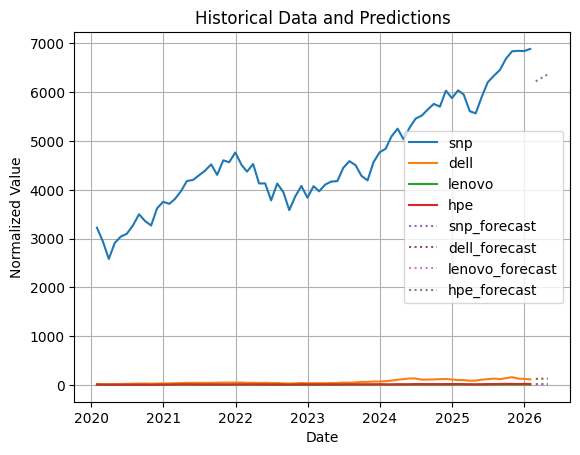

In [ ]:
from matplotlib import pyplot as plt

# Assuming your DataFrame is called 'normalized_sample'
# Get the index for the last 3 months
last_3_months_index = expanded_sample.index[-3:]

# Plot historical data with solid lines
plt.plot(expanded_sample.index[:-3], expanded_sample['snp'][:-3], label='snp', linestyle='-')
plt.plot(expanded_sample.index[:-3], expanded_sample['dell'][:-3], label='dell', linestyle='-')
plt.plot(expanded_sample.index[:-3], expanded_sample['lenovo'][:-3], label='lenovo', linestyle='-')
plt.plot(expanded_sample.index[:-3], expanded_sample['hpe'][:-3], label='hpe', linestyle='-')

# Overlay forecasts with dotted lines for last 3 months
plt.plot(last_3_months_index, expanded_sample['snp'][-3:], label='snp_forecast', linestyle=':')
plt.plot(last_3_months_index, expanded_sample['dell'][-3:], label='dell_forecast', linestyle=':')
plt.plot(last_3_months_index, expanded_sample['lenovo'][-3:], label='lenovo_forecast', linestyle=':')
plt.plot(last_3_months_index, expanded_sample['hpe'][-3:], label='hpe_forecast', linestyle=':')

# Customize the chart
plt.xlabel('Date')
plt.ylabel('Normalized Value')
plt.title('Historical Data and Predictions')
plt.legend()
plt.grid(True)
plt.show()

# YoY Comparison

In [ ]:
expanded_sample['snp_yoy'] = expanded_sample['snp'].pct_change(periods=12) * 100  # YoY for snp
expanded_sample['dell_yoy'] = expanded_sample['dell'].pct_change(periods=12) * 100
expanded_sample['lenovo_yoy'] = expanded_sample['lenovo'].pct_change(periods=12) * 100
expanded_sample['hpe_yoy'] = expanded_sample['hpe'].pct_change(periods=12) * 100

In [ ]:
expanded_sample

,snp,dell,lenovo,hpe,year,month,snp_yoy,dell_yoy,lenovo_yoy,hpe_yoy
2020-01-31,3225.520020,22.660154,3.906627,11.501372,2020.0,1.0,NaN,NaN,NaN,NaN
2020-02-29,2954.219971,18.799053,3.662939,10.560123,2020.0,2.0,NaN,NaN,NaN,NaN
2020-03-31,2584.590088,18.376240,3.167947,8.104410,2020.0,3.0,NaN,NaN,NaN,NaN
2020-04-30,2912.429932,19.835182,3.213638,8.396535,2020.0,4.0,NaN,NaN,NaN,NaN
2020-05-31,3044.310059,23.064383,3.206023,8.104410,2020.0,5.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-12-31,6845.500000,125.879997,9.260000,24.020000,2025.0,12.0,16.387806,11.219772,-4.941455,15.538443
2026-01-31,6888.790039,118.059998,9.000000,22.045000,2026.0,1.0,14.042812,15.567466,0.752356,6.839182
2026-02-28,6226.077645,127.485101,10.656969,21.360303,NaN,NaN,4.560881,25.813687,-4.393862,10.732294
2026-03-31,6297.660337,129.830989,10.742314,21.613780,NaN,NaN,12.220751,44.448902,6.487158,42.699858


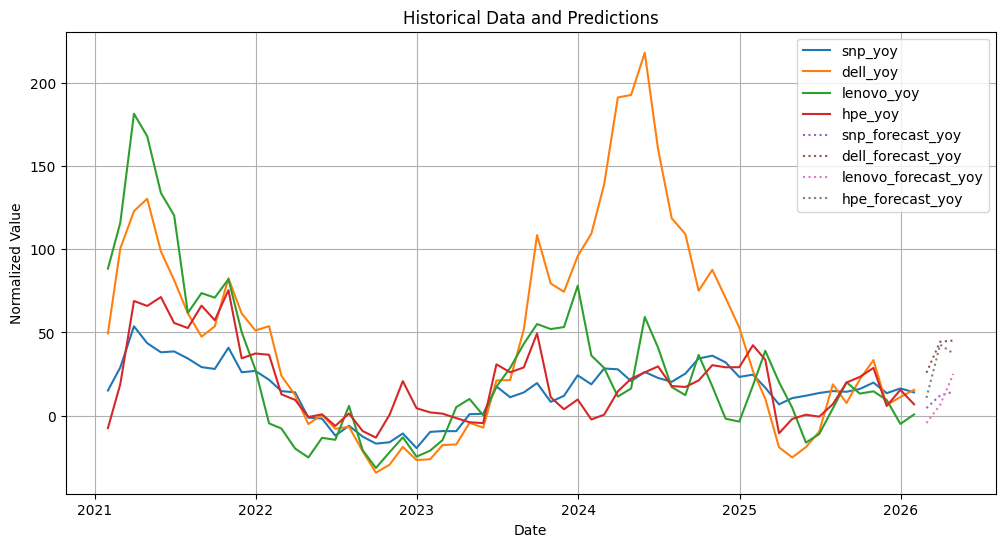

In [ ]:
from matplotlib import pyplot as plt

# Assuming your DataFrame is called 'normalized_sample'
# Get the index for the last 3 months
last_3_months_index = expanded_sample.index[-3:]

plt.figure(figsize=(12, 6))  # Set figsize here

# Plot historical data with solid lines
plt.plot(expanded_sample.index[:-3], expanded_sample['snp_yoy'][:-3], label='snp_yoy', linestyle='-')
plt.plot(expanded_sample.index[:-3], expanded_sample['dell_yoy'][:-3], label='dell_yoy', linestyle='-')
plt.plot(expanded_sample.index[:-3], expanded_sample['lenovo_yoy'][:-3], label='lenovo_yoy', linestyle='-')
plt.plot(expanded_sample.index[:-3], expanded_sample['hpe_yoy'][:-3], label='hpe_yoy', linestyle='-')


# Overlay forecasts with dotted lines for last 3 months
plt.plot(last_3_months_index, expanded_sample['snp_yoy'][-3:], label='snp_forecast_yoy', linestyle=':')
plt.plot(last_3_months_index, expanded_sample['dell_yoy'][-3:], label='dell_forecast_yoy', linestyle=':')
plt.plot(last_3_months_index, expanded_sample['lenovo_yoy'][-3:], label='lenovo_forecast_yoy', linestyle=':')  # Specify figsize here
plt.plot(last_3_months_index, expanded_sample['hpe_yoy'][-3:], label='hpe_forecast_yoy', linestyle=':')  # Specify figsize here

# Customize the chart
plt.xlabel('Date')
plt.ylabel('Normalized Value')
plt.title('Historical Data and Predictions')
plt.legend()
plt.grid(True)
plt.show()

# Normalizing

In [ ]:
#norm_s = sample.apply(lambda x: (x - x.min()) / (x.max() - x.min()))


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Specify the columns you want to normalize
columns_to_normalize = ['snp', 'dell', 'lenovo', 'hpe', 'snp_yoy', 'dell_yoy','lenovo_yoy', 'hpe_yoy']

# Create a scaler object
scaler = MinMaxScaler()

# Create a copy of the DataFrame to avoid modifying the original
normalized = expanded_sample.copy()

# Fit the scaler to the specified columns and transform them
normalized[columns_to_normalize] = scaler.fit_transform(normalized[columns_to_normalize])

# Now 'normalized_expanded_sample' contains the normalized data

In [ ]:
normalized

,snp,dell,lenovo,hpe,year,month,snp_yoy,dell_yoy,lenovo_yoy,hpe_yoy
2020-01-31,0.148908,0.029825,0.089192,0.242001,2020.0,1.0,NaN,NaN,NaN,NaN
2020-02-29,0.085877,0.002944,0.059768,0.186744,2020.0,2.0,NaN,NaN,NaN,NaN
2020-03-31,0.000000,0.000000,0.000000,0.042579,2020.0,3.0,NaN,NaN,NaN,NaN
2020-04-30,0.076167,0.010157,0.005517,0.059728,2020.0,4.0,NaN,NaN,NaN,NaN
2020-05-31,0.106807,0.032640,0.004598,0.042579,2020.0,5.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-12-31,0.989942,0.748457,0.735589,0.976918,2025.0,12.0,0.489775,0.180208,0.124289,0.324030
2026-01-31,1.000000,0.694013,0.704195,0.860974,2026.0,1.0,0.457721,0.197442,0.151049,0.225836
2026-02-28,0.846031,0.759632,0.904266,0.820778,NaN,NaN,0.328111,0.238059,0.126863,0.269780
2026-03-31,0.862662,0.775965,0.914572,0.835659,NaN,NaN,0.432815,0.311930,0.178002,0.630617


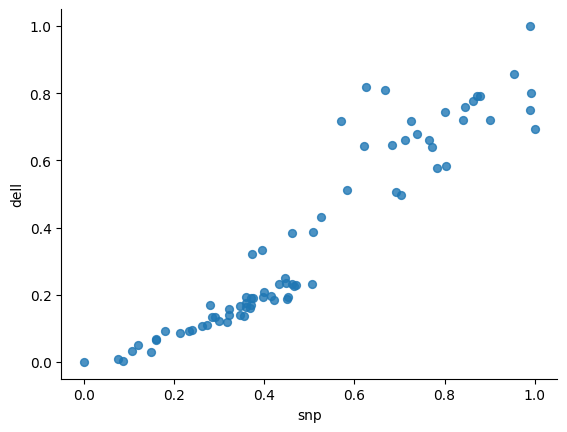

In [ ]:
# @title

from matplotlib import pyplot as plt
normalized.plot(kind='scatter', x='snp', y='dell', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

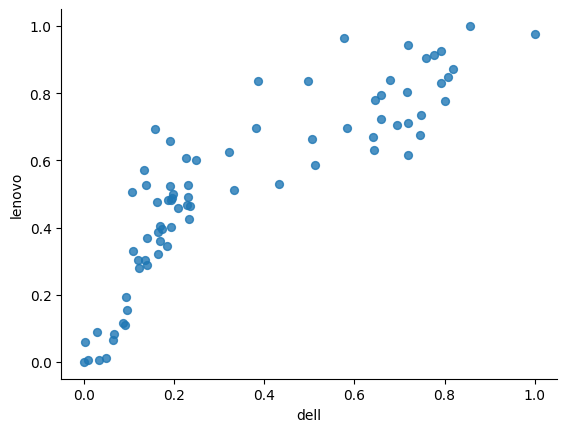

In [ ]:
# @title

from matplotlib import pyplot as plt
normalized.plot(kind='scatter', x='dell', y='lenovo', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

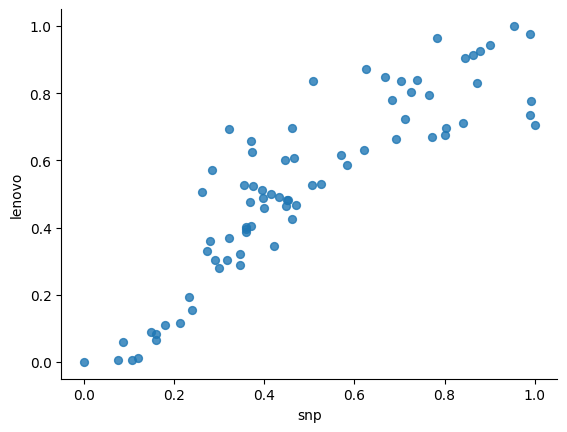

In [ ]:
from matplotlib import pyplot as plt
normalized.plot(kind='scatter', x='snp', y='lenovo', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)


In [ ]:
# Reset index to make 'Date' a regular column
normalized = normalized.reset_index()
normalized.rename(columns={'index': 'Date'}, inplace=True)  # Rename 'index' to 'Date'

expanded_sample = expanded_sample.reset_index()
expanded_sample.rename(columns={'index': 'Date'}, inplace=True)  # Rename 'index' to 'Date'

In [ ]:
normalized

,Date,snp,dell,lenovo,hpe,year,month,snp_yoy,dell_yoy,lenovo_yoy,hpe_yoy
0,2020-01-31,0.148908,0.029825,0.089192,0.242001,2020.0,1.0,NaN,NaN,NaN,NaN
1,2020-02-29,0.085877,0.002944,0.059768,0.186744,2020.0,2.0,NaN,NaN,NaN,NaN
2,2020-03-31,0.000000,0.000000,0.000000,0.042579,2020.0,3.0,NaN,NaN,NaN,NaN
3,2020-04-30,0.076167,0.010157,0.005517,0.059728,2020.0,4.0,NaN,NaN,NaN,NaN
4,2020-05-31,0.106807,0.032640,0.004598,0.042579,2020.0,5.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
71,2025-12-31,0.989942,0.748457,0.735589,0.976918,2025.0,12.0,0.489775,0.180208,0.124289,0.324030
72,2026-01-31,1.000000,0.694013,0.704195,0.860974,2026.0,1.0,0.457721,0.197442,0.151049,0.225836
73,2026-02-28,0.846031,0.759632,0.904266,0.820778,NaN,NaN,0.328111,0.238059,0.126863,0.269780
74,2026-03-31,0.862662,0.775965,0.914572,0.835659,NaN,NaN,0.432815,0.311930,0.178002,0.630617


In [ ]:
expanded_sample

,Date,snp,dell,lenovo,hpe,year,month,snp_yoy,dell_yoy,lenovo_yoy,hpe_yoy
0,2020-01-31,3225.520020,22.660154,3.906627,11.501372,2020.0,1.0,NaN,NaN,NaN,NaN
1,2020-02-29,2954.219971,18.799053,3.662939,10.560123,2020.0,2.0,NaN,NaN,NaN,NaN
2,2020-03-31,2584.590088,18.376240,3.167947,8.104410,2020.0,3.0,NaN,NaN,NaN,NaN
3,2020-04-30,2912.429932,19.835182,3.213638,8.396535,2020.0,4.0,NaN,NaN,NaN,NaN
4,2020-05-31,3044.310059,23.064383,3.206023,8.104410,2020.0,5.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
71,2025-12-31,6845.500000,125.879997,9.260000,24.020000,2025.0,12.0,16.387806,11.219772,-4.941455,15.538443
72,2026-01-31,6888.790039,118.059998,9.000000,22.045000,2026.0,1.0,14.042812,15.567466,0.752356,6.839182
73,2026-02-28,6226.077645,127.485101,10.656969,21.360303,NaN,NaN,4.560881,25.813687,-4.393862,10.732294
74,2026-03-31,6297.660337,129.830989,10.742314,21.613780,NaN,NaN,12.220751,44.448902,6.487158,42.699858
